In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import os
import pandas as pd
import pickle
import json
import dit
import subprocess
from dit import Distribution
from dit.shannon import mutual_information as mi
from dit.shannon import entropy as H
from emergence.calc.dit import DitDistCalc
from emergence.micalc import MutualInfo
from emergence.utils.jvm import JVM
import ptitprince as pt

In [4]:
N = 10  # number of runs per experimental setup
path = "gameDumps/numofbikes"
psis = []
groups = []
agents = 0

In [14]:
# run the experiments
for i in range(3):
    agents += 24
    for j in range(N):
        command = f"go run main.go -agents={agents}"
        subprocess.run(command, shell=True)

In [ ]:
# pairs
for folder in os.listdir(path):
    for file in os.listdir(f"{path}/{folder}"):
        joint_counts = {}
        total = 0
        with open(f"{path}/{folder}/{file}", 'r') as f:
            data = json.load(f)
            all_agent_uuids = data["agentUUIDS"]
            all_bike_uuids = data["bikeUUIDS"]
            agent_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_agent_uuids)}
            bike_uuid_to_idx = {uuid: idx for idx, uuid in enumerate(all_bike_uuids)}
            for iteration in data["iterations"]:
                agentBikes = iteration.get("agentBikes")
                agent_ids = list(agentBikes.keys())
                for i in range(len(agent_ids)):
                    for j in range(i+1, len(agent_ids)):
                        a_id, b_id = agent_ids[i], agent_ids[j]
                        a = agent_uuid_to_idx[a_id]
                        b = agent_uuid_to_idx[b_id]
                        bike_a = bike_uuid_to_idx[agentBikes[a_id]]
                        bike_b = bike_uuid_to_idx[agentBikes[b_id]]
                        same_bike = int(bike_a == bike_b)
                        key = (a, b, same_bike)
                        joint_counts[key] = joint_counts.get(key, 0) + 1
                        total += 1

        outcomes = list(joint_counts.keys())
        probs = [joint_counts[o] / total for o in outcomes]

        dist = Distribution(outcomes, probs)
        calc = DitDistCalc(dist, mi)
        psi = calc.psi(q=2)
        psis.append(psi)
        groups.append(f"{folder}")


one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete
one psi complete


<Axes: xlabel='Number of Bikes', ylabel='Psi'>

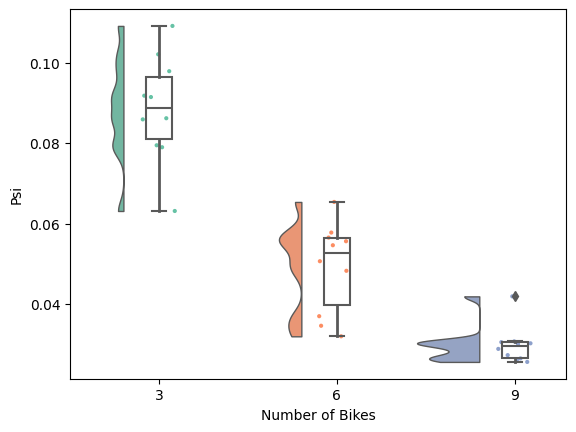

In [7]:
df = pd.DataFrame({
    "Psi": psis,
    "Number of Bikes": groups
})

# Convert group labels to integers for correct x-axis ordering
df["Number of Bikes"] = df["Number of Bikes"].astype(int)
df = df.sort_values("Number of Bikes")

pt.RainCloud(x="Number of Bikes", y="Psi", data=df, orient="v")

In [8]:
# Cleanup
for folder in os.listdir(path):
    for file in os.listdir(f"{path}/{folder}"):
        os.remove(f"{path}/{folder}/{file}")